In [125]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## LIBRARY

#### Kode tersebut merupakan kode untuk mengimport library yang dibutuhkan, seperti OpenCV, Matplotlib.pyplot, dan NumPy:
- Library OpenCV digunakan untuk melakukan berbagai operasi citra seperti membaca, menampilkan, memproses, dan memodifikasi, namun pada jurnal kali ini hanya digunakan untuk membaca dan mengubah citra menjadi grayscale.
- NumPy digunakan untuk representasi citra dalam bentuk matriks array, dan pada jurnal kali ini digunakan untuk melalukan operasi pada matriks dan manipulasi piksel.
- Matplotlib digunakan untuk menampilkan citra hasil pemrosesan berbagai tahap proses

Text(0.5, 1.0, 'Matplotlib')

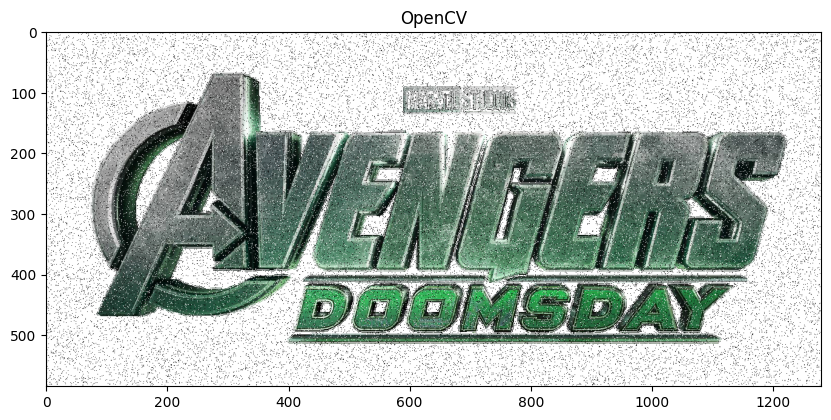

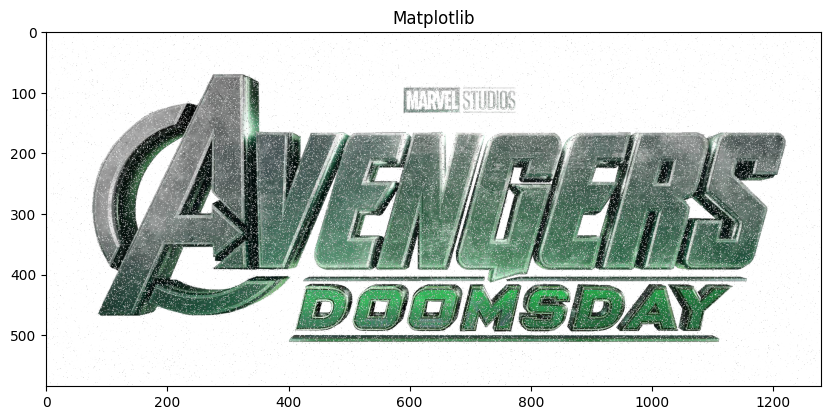

In [126]:
doomCV = cv.imread('doomsday.png')
doomCV = cv.cvtColor(doomCV, cv.COLOR_BGR2RGB)
doomPLT = plt.imread('doomsday.png')
def normalisasi(image):
    image = (image - np.min(image)) / (np.max(image) - np.min(image)) * 255
    return image.astype(np.uint8)
doomPLT = normalisasi(doomPLT)

plt.figure(figsize=(10, 10))
plt.imshow(doomCV)
plt.title('OpenCV')

plt.figure(figsize=(10, 10))
plt.imshow(doomPLT)
plt.title('Matplotlib')

# HASIL ANALISA MEMBACA DENGAN CV2 DAN PLT

Ketika membaca dengan cv tu citra sudah otomatis dibaca dengan format uint8 atau integer dengan rentang 0 - 255, namun masih dalam format BGR bukan RGB, sedangkan jika citra dibaca menggunakan matplotlib citra dibaca dengan format float dengan rentang 0 - 1.0 walau sudah dalam format RGB, sehingga citra yang dibaca dengan matplotlib memerlukan normalisasi terlebih dahulu sebelum dioperasikan.

In [127]:
def filtering(img, size, mode):
    # Mengecek apakah gambar memiliki 3 channel (berwarna) atau 2 channel (grayscale)
    if len(img.shape) == 3:
        height, width, channels = img.shape
    else:
        height, width = img.shape
        channels = 1  # Anggap 1 channel jika grayscale
        img = img[:, :, np.newaxis] # Ubah sementara jadi 3D agar kodenya seragam

    pad = size // 2
    
    # Lakukan padding pada dimensi height dan width saja, dimensi channel (axis=2) jangan di-pad
    padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for c in range(channels): # Loop tambahan untuk warna
                for i in range(height):
                    for j in range(width):
                        region = padded[i:i+size, j:j+size, c]
                        total = 0
                        for val in region.ravel():
                            total += val
                        canvas[i, j, c] = total // area
                        
        case 'median':
            for c in range(channels): # Loop tambahan untuk warna
                for i in range(height):
                    for j in range(width):
                        region = padded[i:i+size, j:j+size, c]
                        values = region.ravel().tolist()
                        values.sort()
                        n = len(values)
                        mid = n // 2
                        if n % 2 == 1:
                            median_val = values[mid]
                        else:
                            median_val = (values[mid - 1] + values[mid]) // 2
                        canvas[i, j, c] = median_val
                        
        case 'modus':
            for c in range(channels): # Loop tambahan untuk warna
                for i in range(height):
                    for j in range(width):
                        region = padded[i:i+size, j:j+size, c]
                        values = region.ravel()
                        count = {}
                        for val in values:
                            if val in count:
                                count[val] += 1
                            else:
                                count[val] = 1
                        max_count = 0
                        mode_val = 0
                        for val, freq in count.items():
                            if freq > max_count:
                                max_count = freq
                                mode_val = val
                        canvas[i, j, c] = mode_val

    # Jika input aslinya grayscale, kembalikan ke bentuk 2D lagi
    if channels == 1:
        return canvas[:, :, 0]
        
    return canvas

In [128]:
kernel3f1 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

def erosi_rgb(image, kernel):
    height, width, channels = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    
    # Siapkan matriks kosong dengan ukuran yang sama dan tipe data uint8
    hasil = np.zeros((height, width, channels), dtype=np.uint8)
    
    # Loop untuk setiap channel warna (R, G, B)
    for c in range(channels):
        for i in range(center, height - center):
            for j in range(center, width - center):
                
                # Inisialisasi nilai minimum dengan nilai tertinggi (255)
                min_val = 255
                
                # Loop mencari nilai terkecil di dalam area kernel
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            # Ambil nilai intensitas asli piksel tetangga
                            piksel_tetangga = image[i + k - center, j + l - center, c]
                            if piksel_tetangga < min_val:
                                min_val = piksel_tetangga
                
                # Set nilai minimum yang ditemukan ke matriks hasil
                hasil[i, j, c] = min_val
                
    return hasil

Text(0.5, 1.0, '(Matplotlib)')

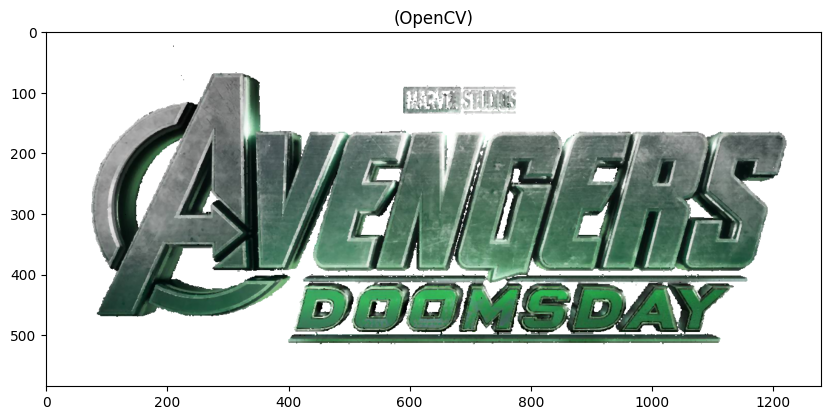

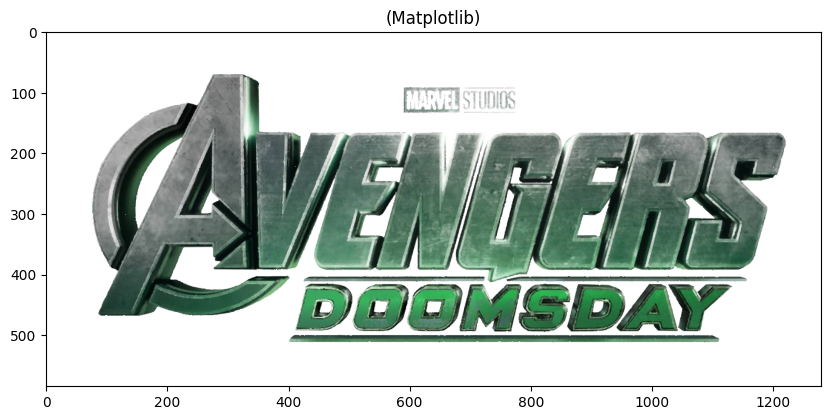

In [129]:
doomCVBersih = filtering(doomCV, 3, 'median')
doomPLTBersih = filtering(doomPLT, 3, 'median')

plt.figure(figsize=(10, 10))
plt.imshow(doomCVBersih)
plt.title('(OpenCV)')

plt.figure(figsize=(10, 10))
plt.imshow(doomPLTBersih)
plt.title('(Matplotlib)')

# HASIL PEMBERSIHAN MENGGUNAKAN FILTERING MEDIAN

Saya membersihkan noise pada kedua citra dengan menggunakan filtering median, namun hasil dari kedua citra itu berbeda. Pada citra cv, citra yang dihasilkan lebih tidak rata pada garis tepinya, sedangkan pada citra matplotlib rapi dan hasil pembersihannya lebih bagus juga ketimbang citra cv

In [130]:
def threshold(image, value, min_val, max_val):
    img = np.array(image)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] > value:
                img[i, j] = max_val
            else:
                img[i, j] = min_val 
    return img

def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height // 2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil 

def erosi(image, kernel): 
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height): 
                for l in range(k_width): 
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0: 
                        cocok = False 
                        break 
                if not cocok: 
                    break 
            if cocok: 
                hasil[i, j] = 255 
    return hasil

def thickening(img, kernel, iterasi=1): 
    hasil = img.copy() 
    for _ in range(iterasi): 
        hasil = dilasi(hasil, kernel) 
    return hasil

def gradientMorph(erosi, dilasi):
    hasil = dilasi - erosi
    return hasil

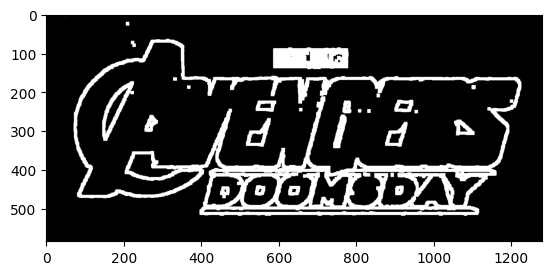

In [131]:
doomG = cv.cvtColor(doomPLTBersih, cv.COLOR_BGR2GRAY)
doomT = threshold(doomG, 250, 0, 255)
doomD = dilasi(doomT, kernel3f1)
doomE = erosi(doomT, kernel3f1)
doomGM = gradientMorph(doomE, doomD)
doomTHICK = thickening(doomGM, kernel3f1, 3)

plt.imshow(doomTHICK, cmap = 'gray')

# MEMBUAT MASKER

Di sini saya menggunakan opersai merubah jadi grayscale, terus dilanjutkan dengan operasi threshold, dilasi dan erosi, gradient morfologi, serta thickening. Pertama-tama saya menggunakan cv.cvtColor untuk merubah citra menjadi grayscale, kemudian melakukan operasi threshold unuk membuat citranya menjadi hitam putih tegas, sehingga bisa dibedakan yang mana yang akan di gunakan sebagai masker, kemudian operasi dilasi & erosi dilakukan untuk memperluas batas tepi objek (membuat huruf menjadi lebih gemuk) dan erosi untuk mengikis batas terluar dari objerk (membuat huruf lebih kurus), kemudian dilanjutkan dengan operasi gradient morfologi untuk atau pengurangan dilasi dengan erosi, ini dilakukan untuk mengekstraksi garis kontur(tepi luar objek) sehingga hanya menyisakan garis terluar dari objek tersebut saja yang berwarna putih, kemudian terakhir saya menggunakan operasi thickening sebanyak 3 iterasi guna menebalkan kontur atau garis terluar dari objek agar pada saat digabungkan dengan citra asli, masker masih terlihat.

In [132]:
def sorot_tepi(citra_asli, mask_tepi):
    # Pastikan citra_asli dalam format RGB (3 dimensi)
    # Jika citra_asli masih grayscale, ubah dulu ke RGB dengan np.stack
    if citra_asli.ndim == 2:
        citra_rgb = np.stack([citra_asli] * 3, axis=-1)
    else:
        citra_rgb = citra_asli.copy()
        
    # Buat kondisi boolean di mana piksel pada masker bernilai putih (255)
    mask_bool = (mask_tepi == 255)
    
    # Ubah warna piksel tersebut di citra asli menjadi MERAH (R=255, G=0, B=0)
    citra_rgb[mask_bool, 0] = 255  # Kanal Red
    citra_rgb[mask_bool, 1] = 0    # Kanal Green
    citra_rgb[mask_bool, 2] = 0    # Kanal Blue
    
    return citra_rgb

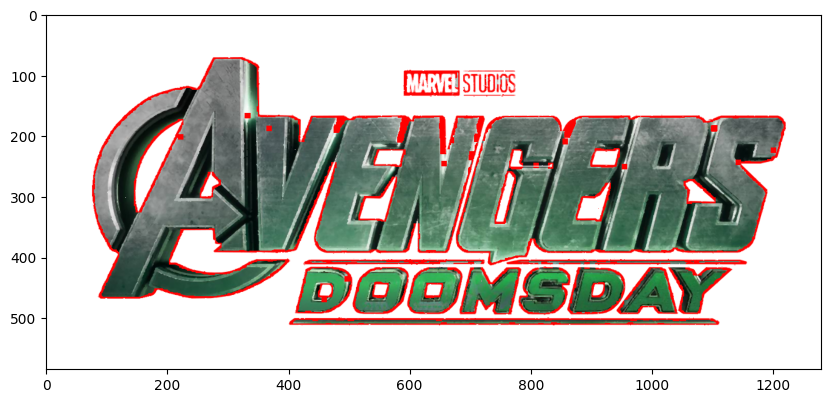

In [133]:
hasilAkhir = sorot_tepi(doomPLTBersih, doomTHICK)

plt.figure(figsize=(10, 10))
plt.imshow(hasilAkhir)

### Analisis Kegunaan Fungsi `sorot_tepi` Terhadap Hasil Akhir Citra

Fungsi `sorot_tepi(citra_asli, mask_tepi)` merupakan tahap final (*rendering*) yang berfungsi untuk menggabungkan informasi spasial dari masker biner dengan data visual dari citra asli guna menghasilkan efek penekanan (*highlighting*) kontur. 

Secara teknis, berikut adalah kegunaan dari setiap baris logika di dalam fungsi tersebut terhadap gambar hasil akhir:

#### 1. Validasi Dimensi dan Standarisasi Array (`if citra_asli.ndim == 2`)
* **Kegunaan:** Memeriksa apakah citra asli bertipe *grayscale* (2 dimensi) atau warna (3 dimensi). Jika citra input bertipe *grayscale*, fungsi akan menduplikasi kanal tunggal tersebut sebanyak 3 kali menggunakan `np.stack(..., axis=-1)` agar berubah menjadi format RGB.
* **Dampak pada Gambar:** Karena gambar logo `doomPLTBersih` Anda sudah berbentuk citra warna 3-kanal (RGB), baris ini langsung mengeksekusi blok `else` untuk menyalin array asal (`citra_asli.copy()`). Langkah ini memastikan manipulasi piksel warna merah nantinya tidak merusak variabel citra asli di memori.

#### 2. Pembuatan Matriks Kondisi Spasial (`mask_bool = (mask_tepi == 255)`)
* **Kegunaan:** Membuat matriks logika (*boolean mask*) berukuran sama dengan citra, di mana koordinat akan bernilai `True` jika piksel pada `doomTHICK` berwarna putih mutlak ($255$), dan bernilai `False` jika berwarna hitam ($0$).
* **Dampak pada Gambar:** Langkah ini mengunci koordinat persis di mana letak garis tepi hasil operasi morfologi berada, sehingga proses pewarnaan nantinya tidak akan meleset ke latar belakang ataupun ke bagian dalam huruf.

#### 3. Substitusi Warna Array Multi-Kanal (`citra_rgb[mask_bool, 0/1/2] = ...`)
* **Kegunaan:** Melakukan penggantian nilai intensitas warna secara paksa (*force injection*) hanya pada koordinat piksel yang bernilai `True` di dalam `mask_bool`. Nilai kanal warna diubah menjadi komponen warna merah murni (Red-Green-Blue):
  * `citra_rgb[mask_bool, 0] = 255` $\rightarrow$ Memaksimalkan kanal **Red** ke nilai tertinggi.
  * `citra_rgb[mask_bool, 1] = 0`   $\rightarrow$ Mematikan kanal **Green**.
  * `citra_rgb[mask_bool, 2] = 0`   $\rightarrow$ Mematikan kanal **Blue**.
* **Dampak pada Gambar:** Mengubah piksel putih pada masker biner kontur menjadi garis merah menyala yang kontras. Karena piksel lain yang bernilai `False` (latar belakang hitam dan badan teks) diabaikan, bagian logo asli di dalam bingkai kontur tersebut tetap mempertahankan warna hijau murni dan gradasi silver metaliknya secara utuh.

---

### Kesimpulan Visual
Fungsi ini berperan sebagai jembatan yang menyatukan hasil ekstraksi fitur geometri tingkat tinggi (masker kontur luar teks) dengan citra mentah. Tanpa fungsi ini, masker morfologi hanya akan menjadi gambar hitam-putih biasa tanpa arti visual komersial. Hasil akhir menunjukkan garis merah yang tebal, presisi, solid, dan tidak terputus mengitari seluruh tepian teks *Avengers: Doomsday* tanpa menghasilkan kebocoran warna (*color bleeding*) ke area lain.